In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

trials = 5000
Pt_dB = np.arange(0, 31, 2)   # SNR sweep in dB
N0 = 1
a1, a2 = 0.2, 0.8             # Power allocation (strong, weak)
R = 1.0                       # Target rate (bits/s/Hz)
Pr_fraction = 0.3             # Relay power fraction


In [2]:
def generate_channel():
    return (np.random.randn() + 1j*np.random.randn())/np.sqrt(2)

def sinr_strong(h1, Pt, a1, N0):
    return (a1*Pt*abs(h1)**2)/N0

def sinr_weak_direct(h2, Pt, a1, a2, N0):
    return (a2*Pt*abs(h2)**2)/(a1*Pt*abs(h2)**2 + N0)

def sinr_weak_coop(h2, h12, Pt, a1, a2, Pr, N0):
    sinr_direct = sinr_weak_direct(h2, Pt, a1, a2, N0)
    sinr_relay = (Pr*abs(h12)**2)/N0
    return sinr_direct + sinr_relay


In [3]:
def outage_probability(Pt, cooperative=True):
    outages = 0
    for _ in range(trials):
        h1, h2, h12 = generate_channel(), generate_channel(), generate_channel()
        if cooperative:
            Pr = Pr_fraction * Pt
            sinr = sinr_weak_coop(h2, h12, Pt, a1, a2, Pr, N0)
        else:
            sinr = sinr_weak_direct(h2, Pt, a1, a2, N0)
        if np.log2(1 + sinr) < R:
            outages += 1
    return outages / trials


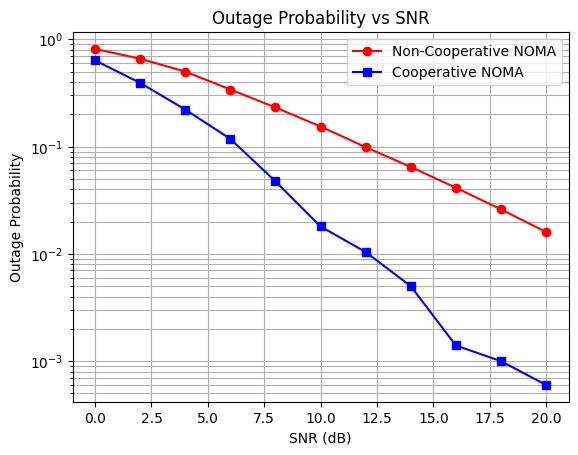

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define SNR range
Pt_dB = np.arange(0, 21, 2)   # 0 to 20 dB in steps of 2

# Lists to store results
out_noncoop = []
out_coop = []

# Simulation loop
for snr_db in Pt_dB:
    Pt = 10**(snr_db/10)
    out_noncoop.append(outage_probability(Pt, cooperative=False))
    out_coop.append(outage_probability(Pt, cooperative=True))

# Create DataFrame with results
df = pd.DataFrame({
    "SNR(dB)": Pt_dB,
    "Outage_NonCoop": out_noncoop,
    "Outage_Coop": out_coop
})

# Save results to CSV
df.to_csv("outage_results_.csv", index=False)

# Plot results
plt.semilogy(Pt_dB, out_noncoop, 'r-o', label='Non-Cooperative NOMA')
plt.semilogy(Pt_dB, out_coop, 'b-s', label='Cooperative NOMA')
plt.xlabel('SNR (dB)')
plt.ylabel('Outage Probability')
plt.title('Outage Probability vs SNR')
plt.legend()
plt.grid(True, which="both")

# Save plot to plots folder
plt.savefig("plots/outage_curve_.png")
plt.show()



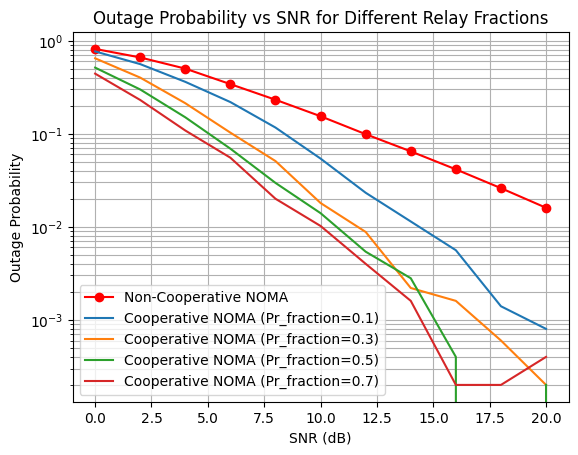

In [6]:
# Sweep multiple relay power fractions
relay_fractions = [0.1, 0.3, 0.5, 0.7]   # Try different cooperation strengths
out_curves = {}

for frac in relay_fractions:
    Pr_fraction = frac
    out_coop_frac = []
    for snr_db in Pt_dB:
        Pt = 10**(snr_db/10)
        out_coop_frac.append(outage_probability(Pt, cooperative=True))
    out_curves[frac] = out_coop_frac

# Plot results
# Plot results
plt.semilogy(Pt_dB, out_noncoop, 'r-o', label='Non-Cooperative NOMA')
for frac, curve in out_curves.items():
    plt.semilogy(Pt_dB, curve, label=f'Cooperative NOMA (Pr_fraction={frac})')

plt.xlabel('SNR (dB)')
plt.ylabel('Outage Probability')
plt.title('Outage Probability vs SNR for Different Relay Fractions')
plt.legend()
plt.grid(True, which="both")

# Save the figure into plots folder
plt.savefig("plots/outage_relay_sweep.png")

plt.show()
